# Compare framing detection across two models

Updated comparison notebook: robust Path settings, one grouping cell, individual topic groups, gender groups, and decades. Original saved outputs have been cleared to avoid presenting stale results.

Edit Section 1, then restart the kernel and Run All. Default inputs point to the original Desktop CSVs; outputs go to `output_updated` in the kernel working directory. Requires pandas, numpy, matplotlib and Pillow. Group summaries use model A metadata and describe framing agreement within groups, not agreement on the metadata itself.


## 1. Settings

The original dataset paths are filled in below. Model A is Gemma; model B is Qwen. Leave `JOIN_KEYS = None` to match on `_row_id`, falling back to `doc_id` and `segment_index`. Group summaries use model A's metadata.

In [20]:
from pathlib import Path

CSV_A = Path('data/frames_debate_complete_gemma3_27b.csv')
CSV_B = Path('data/frames_debate_complete_qwen3.5_35b.csv')
OUTPUT_DIR = Path('output')

NAME_A = 'Gemma 3 27B'
NAME_B = 'Qwen 3.5 35B'
JOIN_KEYS = None  # Example: ['doc_id', 'segment_index']
GROUP_BY = ['decade', 'relevance_to_original_topic', 'gender_mentioned', 'topic_type']  # Separate summaries; [] disables them.
TOPIC_SEPARATOR = ';'  # Set to the actual separator in topic_type, e.g. ';' or ','.
# Each topic gets its own group; a multi-topic segment can contribute to multiple groups.
# Decades are calendar decades: 1900-1909, 1910-1919, etc.; missing years form '(missing)'.
EXPORT_DISAGREEMENTS = True
MAKE_PLOTS = True
PREVIEW_ROWS = 10

## 2. Comparison definitions

- **Frame label:** equality of `NOT_FRAMED`, `SINGLE_FRAME`, or `MULTIPLE_FRAMES`.
- **Types without polarity:** exact equality of unordered sets of base types.
- **Types with polarity:** exact equality of unordered sets of type/polarity pairs.
- **Joint comparisons:** both the label and the corresponding type set must agree.

Order and duplicate frame tokens do not matter. Case and whitespace are normalized. Two empty type sets are valid agreement when both labels are `NOT_FRAMED`. Processing failures and segment-text mismatches are excluded. Missing or invalid types are excluded from type statistics; usable labels can still contribute to label agreement. Every metric shows its own eligible denominator.

Cohen's kappa corrects for agreement expected from the marginal distributions. For type sets, each complete set is treated as a nominal category. Undefined statistics are blank in exported CSVs. These measures describe agreement rather than accuracy against human annotations.

In [21]:
from __future__ import annotations

import json
import re
import numpy as np
import pandas as pd

LABELS = {'NOT_FRAMED', 'SINGLE_FRAME', 'MULTIPLE_FRAMES'}
NAMES = {
    'frame_label': 'Frame label',
    'frame_types_without_polarity': 'Frame types without polarity',
    'frame_types_with_polarity': 'Frame types with polarity',
    'label_and_types_without_polarity': 'Label + types without polarity',
    'label_and_types_with_polarity': 'Label + types with polarity',
}

### Parsing, alignment, and quality checks
These helpers preserve identifiers and Chinese text, validate joins, and distinguish empty frame sets from failed predictions.

In [22]:
def normalize(value: str) -> str:
    return " ".join(value.strip().split()).casefold()



def parse_frames(value: str) -> tuple[frozenset[str], frozenset[str]]:
    """Order and duplicate tokens do not matter; polarity must be parenthesized."""
    signed, bases = set(), set()
    if not value.strip():
        return frozenset(), frozenset()
    for token in value.split("|"):
        match = re.fullmatch(r"\s*([^()|]+?)\s*\(\s*([^()|]+?)\s*\)\s*", token)
        if not match:
            raise ValueError(f"Invalid frame token: {token!r}; expected 'type (polarity)'")
        base, polarity = (normalize(x) for x in match.groups())
        signed.add(f"{base} ({polarity})")
        bases.add(base)
    return frozenset(signed), frozenset(bases)



def format_frame_set(values) -> str:
    return "|".join(sorted(values))



def jaccard(a, b) -> float:
    return len(a & b) / len(a | b) if a | b else 1.0



def kappa(a, b) -> float:
    """Unweighted Cohen's kappa; NaN when empty or expected agreement is 1."""
    if not len(a):
        return float("nan")
    a, b = pd.Series(list(a)), pd.Series(list(b))
    observed = float((a == b).mean())
    expected = float(a.value_counts(normalize=True).mul(
        b.value_counts(normalize=True), fill_value=0).sum())
    return (observed - expected) / (1 - expected) if expected < 1 - 1e-12 else float("nan")



def write_csv(frame, path, index=False):
    frame.to_csv(path, index=index, encoding="utf-8-sig")



def load(path: Path) -> pd.DataFrame:
    # Keep literal NA strings and identifiers intact; only blank fields are blank.
    df = pd.read_csv(path, dtype=str, keep_default_na=False, encoding="utf-8-sig")
    missing = {"frame_label", "frame_type"} - set(df.columns)
    if missing:
        raise ValueError(f"{path}: missing columns {sorted(missing)}")
    if "frame_processing_error" not in df:
        df["frame_processing_error"] = ""
    return df



def align(a, b, keys):
    for name, df in [("A", a), ("B", b)]:
        missing = set(keys) - set(df.columns)
        if missing:
            raise ValueError(f"Model {name}: missing join columns {sorted(missing)}")
        if df[keys].apply(lambda s: s.str.strip().eq("")).any().any():
            raise ValueError(f"Model {name}: blank join identifiers")
        if df.duplicated(keys).any():
            examples = df.loc[df.duplicated(keys, keep=False), keys].head().to_dict("records")
            raise ValueError(f"Model {name}: duplicate join identifiers: {examples}")
    joined = a.merge(b, on=keys, how="outer", suffixes=("_a", "_b"),
                     validate="one_to_one", indicator=True)
    joined["_merge"] = joined["_merge"].astype(str)
    return joined.fillna("")



def prepare(matched):
    """Keep all matched rows; attach quality reasons and metric eligibility."""
    result = matched.copy()
    records = []
    for _, row in result.iterrows():
        reasons = []
        text_mismatch = ("segment_text_a" in row and "segment_text_b" in row
                         and row.segment_text_a != row.segment_text_b)
        if text_mismatch:
            reasons.append("segment_text_mismatch")
        common_ok = not text_mismatch
        parsed = {}
        label_ok, type_ok = {}, {}
        for side in ("a", "b"):
            label = row[f"frame_label_{side}"].strip().upper()
            error = normalize(row.get(f"frame_processing_error_{side}", ""))
            if error in {"true", "1", "yes"}:
                reasons.append(f"processing_error_{side}")
                common_ok = False
            elif error not in {"", "false", "0", "no"}:
                reasons.append(f"unknown_processing_error_flag_{side}")
                common_ok = False
            label_ok[side] = label in LABELS
            if not label_ok[side]:
                reasons.append(f"missing_or_unknown_frame_label_{side}")
            try:
                signed, bases = parse_frames(row[f"frame_type_{side}"])
                # Blank NOT_FRAMED is a valid empty set, never a missing prediction.
                type_ok[side] = label_ok[side] and (
                    (label == "NOT_FRAMED" and not signed)
                    or (label in {"SINGLE_FRAME", "MULTIPLE_FRAMES"} and bool(signed)))
                if not type_ok[side]:
                    reasons.append(f"missing_or_inconsistent_frame_type_{side}")
                if label == "SINGLE_FRAME" and len(bases) != 1 and signed:
                    reasons.append(f"label_type_count_warning_{side}")
                if label == "MULTIPLE_FRAMES" and len(bases) < 2 and signed:
                    reasons.append(f"label_type_count_warning_{side}")
            except ValueError:
                signed, bases = frozenset(), frozenset()
                type_ok[side] = False
                reasons.append(f"malformed_frame_type_{side}")
            parsed[side] = (signed, bases, label)
        label_valid = common_ok and all(label_ok.values())
        types_valid = common_ok and all(type_ok.values())
        sa, ba, la = parsed["a"]
        sb, bb, lb = parsed["b"]
        record = {"quality_reasons": ";".join(reasons),
                  "frame_label_eligible": label_valid,
                  "frame_types_without_polarity_eligible": types_valid,
                  "frame_types_with_polarity_eligible": types_valid,
                  "label_and_types_without_polarity_eligible": label_valid and types_valid,
                  "label_and_types_with_polarity_eligible": label_valid and types_valid,
                  "frame_label_agree": la == lb if label_valid else pd.NA,
                  "frame_types_without_polarity_agree": ba == bb if types_valid else pd.NA,
                  "frame_types_with_polarity_agree": sa == sb if types_valid else pd.NA,
                  "label_and_types_without_polarity_agree": la == lb and ba == bb if label_valid and types_valid else pd.NA,
                  "label_and_types_with_polarity_agree": la == lb and sa == sb if label_valid and types_valid else pd.NA,
                  "jaccard_without_polarity": jaccard(ba, bb) if types_valid else np.nan,
                  "jaccard_with_polarity": jaccard(sa, sb) if types_valid else np.nan,
                  "polarity_only_disagreement": types_valid and ba == bb and sa != sb}
        for side, (signed, bases, label) in parsed.items():
            record.update({f"signed_set_{side}": signed, f"base_set_{side}": bases,
                           f"normalized_label_{side}": label,
                           f"normalized_types_with_polarity_{side}": format_frame_set(signed),
                           f"normalized_types_without_polarity_{side}": format_frame_set(bases)})
        for mode, x, y in [("with_polarity", sa, sb), ("without_polarity", ba, bb)]:
            record[f"types_only_a_{mode}"] = format_frame_set(x - y) if types_valid else ""
            record[f"types_only_b_{mode}"] = format_frame_set(y - x) if types_valid else ""
        records.append(record)
    # Fixed empty schema also supports files with no overlapping keys.
    if not records:
        empty = prepare(pd.DataFrame([{
            "frame_label_a": "", "frame_label_b": "", "frame_type_a": "", "frame_type_b": ""
        }])).iloc[:0]
        return pd.concat([result.reset_index(drop=True), empty.drop(columns=[
            "frame_label_a", "frame_label_b", "frame_type_a", "frame_type_b"])], axis=1)
    return pd.concat([result.reset_index(drop=True), pd.DataFrame(records)], axis=1)



def exportable(df):
    return df.drop(columns=["signed_set_a", "signed_set_b", "base_set_a", "base_set_b"], errors="ignore")

### Statistics and chart helpers
Per-frame agreement includes joint absences. Positive agreement omits joint absences: `2 × both_present / (2 × both_present + a_only + b_only)`.

In [23]:
def summarize(df):
    rows = []
    for metric in NAMES:
        valid = df.loc[df[f"{metric}_eligible"].eq(True)]
        count = int(valid[f"{metric}_agree"].eq(True).sum())
        if metric == "frame_label":
            x, y = valid.normalized_label_a, valid.normalized_label_b
        elif metric.startswith("label_and"):
            mode = "with_polarity" if metric.endswith("_with_polarity") else "without_polarity"
            x = list(zip(valid.normalized_label_a, valid[f"normalized_types_{mode}_a"]))
            y = list(zip(valid.normalized_label_b, valid[f"normalized_types_{mode}_b"]))
            # JSON encodes tuples unambiguously for categorical kappa.
            x, y = [json.dumps(v) for v in x], [json.dumps(v) for v in y]
        else:
            mode = metric.removeprefix("frame_types_")
            x, y = valid[f"normalized_types_{mode}_a"], valid[f"normalized_types_{mode}_b"]
        rows.append({"metric": metric, "n_eligible": len(valid), "n_agree": count,
                     "n_disagree": len(valid) - count, "n_excluded": len(df) - len(valid),
                     "agreement_pct": 100 * count / len(valid) if len(valid) else np.nan,
                     "cohens_kappa": kappa(x, y)})
    return pd.DataFrame(rows)



def per_frame_statistics(df):
    valid = df.loc[df.frame_types_with_polarity_eligible.eq(True)]
    rows = []
    for mode, column in [("without_polarity", "base_set"), ("with_polarity", "signed_set")]:
        vocabulary = sorted(set().union(*valid[f"{column}_a"], *valid[f"{column}_b"]))
        for frame in vocabulary:
            a = valid[f"{column}_a"].map(lambda s: frame in s)
            b = valid[f"{column}_b"].map(lambda s: frame in s)
            both = int((a & b).sum())
            a_only, b_only = int((a & ~b).sum()), int((~a & b).sum())
            neither = int((~a & ~b).sum())
            shared_polarity = []
            if mode == "without_polarity":
                for sa, sb in zip(valid.signed_set_a, valid.signed_set_b):
                    pa = {s for s in sa if s.rsplit(" (", 1)[0] == frame}
                    pb = {s for s in sb if s.rsplit(" (", 1)[0] == frame}
                    if pa and pb:
                        shared_polarity.append(pa == pb)
            rows.append({"mode": mode, "frame": frame, "n_eligible": len(valid),
                         "a_present": int(a.sum()), "b_present": int(b.sum()),
                         "a_prevalence_pct": 100 * a.mean(), "b_prevalence_pct": 100 * b.mean(),
                         "both_present": both, "a_only": a_only, "b_only": b_only,
                         "neither_present": neither, "agreement_pct": 100 * (a == b).mean(),
                         "cohens_kappa": kappa(a, b),
                         "positive_agreement_pct": 200 * both / (2 * both + a_only + b_only)
                         if 2 * both + a_only + b_only else np.nan,
                         "polarity_shared_frame_n": len(shared_polarity) if mode == "without_polarity" else np.nan,
                         "polarity_shared_frame_agreement_pct": 100 * np.mean(shared_polarity)
                         if shared_polarity else np.nan})
    return pd.DataFrame(rows, columns=["mode", "frame", "n_eligible", "a_present", "b_present",
        "a_prevalence_pct", "b_prevalence_pct", "both_present", "a_only", "b_only",
        "neither_present", "agreement_pct", "cohens_kappa", "positive_agreement_pct",
        "polarity_shared_frame_n", "polarity_shared_frame_agreement_pct"])



def charts(summary, confusion, per_frame, distribution, out, names):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
    def save(fig, name):
        fig.savefig(out / name, dpi=180, bbox_inches="tight")
        plt.close(fig)
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh([NAMES[m] for m in summary.metric], summary.agreement_pct, color="#286d96")
    ax.set_xlim(0, 115)
    ax.set_xlabel("Exact agreement (%)")
    ax.set_title(f"{names[0]} vs {names[1]}")
    for bar, (_, r) in zip(bars, summary.iterrows()):
        if pd.notna(r.agreement_pct):
            ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f"{r.agreement_pct:.1f}% (n={r.n_eligible:,})", va="center", fontsize=9)
        else:
            ax.text(1, bar.get_y() + bar.get_height()/2,
                    "No eligible segments (n=0)", va="center", fontsize=9)
    ax.invert_yaxis()
    save(fig, "agreement.png")
    fig, ax = plt.subplots(figsize=(8, 6))
    matrix = confusion.to_numpy(dtype=int)
    img = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=max(1, matrix.max()))
    for i in range(len(confusion)):
        total = matrix[i].sum()
        for j in range(len(confusion.columns)):
            ax.text(j, i, f"{matrix[i,j]:,}\n{100*matrix[i,j]/total:.1f}%" if total else "0\nn/a",
                    ha="center", va="center", color="white" if matrix[i,j] > matrix.max()/2 else "black")
    ax.set_xticks(range(len(confusion.columns)), confusion.columns, rotation=20, ha="right")
    ax.set_yticks(range(len(confusion)), confusion.index)
    ax.set_xlabel(names[1]); ax.set_ylabel(names[0])
    ax.set_title("Frame label cross-tabulation: count and row %")
    fig.colorbar(img, ax=ax, label="Segments")
    save(fig, "frame_label_confusion.png")
    for mode in ["without_polarity", "with_polarity"]:
        data = per_frame.loc[per_frame["mode"].eq(mode)].sort_values("a_prevalence_pct")
        if data.empty:
            continue
        fig, ax = plt.subplots(figsize=(10, max(4, len(data) * .4)))
        y = np.arange(len(data))
        ax.barh(y-.18, data.a_prevalence_pct, height=.35, label=names[0], color="#286d96")
        ax.barh(y+.18, data.b_prevalence_pct, height=.35, label=names[1], color="#df8b3e")
        ax.set_yticks(y, data.frame)
        ax.set_xlabel("Segments containing frame (%)")
        ax.set_xlim(0, 100); ax.legend()
        ax.set_title(f"Frame prevalence {mode.replace('_', ' ')} (n={int(data.n_eligible.iloc[0]):,})")
        save(fig, f"frame_prevalence_{mode}.png")
    fig, ax = plt.subplots(figsize=(8, 5))
    categories = sorted(LABELS)
    y = np.arange(len(categories))
    for i, side in enumerate(("a", "b")):
        values = distribution.loc[distribution.model_side.eq(side)].set_index("frame_label").reindex(categories)
        ax.bar(y + (i-.5)*.35, values.prevalence_pct, width=.35, label=names[i],
               color=["#286d96", "#df8b3e"][i])
    ax.set_xticks(y, categories); ax.set_ylabel("Eligible segments (%)")
    ax.set_title("Frame label distributions on the same paired population")
    ax.legend(); save(fig, "frame_label_distribution.png")

## 3. Load and align segments

Matching uses identifiers rather than row position. Blank or duplicate identifiers stop execution. Unmatched segments are exported separately and excluded from agreement percentages.

In [24]:
CSV_A, CSV_B, OUTPUT_DIR = map(Path, (CSV_A, CSV_B, OUTPUT_DIR))
a, b = load(CSV_A), load(CSV_B)
keys = JOIN_KEYS or (["_row_id"] if "_row_id" in a and "_row_id" in b else ["doc_id", "segment_index"])
def model_name(df, override, path):
    values = df.get("framing_model", pd.Series(dtype=str))
    unique = values[values.ne("")].unique()
    return override or (unique[0] if len(unique) == 1 else path.stem)
names = (model_name(a, NAME_A, CSV_A), model_name(b, NAME_B, CSV_B))
joined = align(a, b, keys)

display(pd.DataFrame({'model': names, 'input_rows': [len(a), len(b)]}))
display(joined['_merge'].value_counts().rename('segments').to_frame())

,model,input_rows
0,Gemma 3 27B,4634
1,Qwen 3.5 35B,4634


,segments
_merge,
both,4634


## 4. Quality checks and headline agreement

A pair is one matched segment, with one prediction from each model. `quality_reasons` can contain several semicolon-separated reasons. `_a` refers to model A (Gemma) and `_b` to model B (Qwen).

- Text mismatch or a true/unknown `frame_processing_error` flag excludes the pair from all metrics.
- Missing/unknown labels exclude label metrics and, in this implementation, type metrics too.
- Missing, inconsistent, or malformed types exclude type and joint metrics; valid labels can still contribute to label agreement.
- `label_type_count_warning` checks the number of distinct base types: SINGLE_FRAME should have one, MULTIPLE_FRAMES at least two. Otherwise usable predictions remain eligible. For example, two polarities of modernization still count as one base type.

The checks use `frame_processing_error`; other error columns are retained for inspection but not independently checked. A disagreement between two valid predictions is not itself a quality issue. Read each metric's `n_eligible` and `n_excluded`, and inspect `quality_issues.csv`.


In [25]:
out = OUTPUT_DIR
out.mkdir(parents=True, exist_ok=True)
write_csv(joined.loc[joined._merge.ne("both")], out / "unmatched_segments.csv")
pairs = prepare(joined.loc[joined._merge.eq("both")])
write_csv(exportable(pairs), out / "segment_comparisons.csv")
write_csv(exportable(pairs.loc[pairs.quality_reasons.ne("")]), out / "quality_issues.csv")
summary = summarize(pairs)
write_csv(summary, out / "agreement_summary.csv")

display(summary.round({'agreement_pct': 2, 'cohens_kappa': 4}))
quality_rows = pairs.loc[pairs.quality_reasons.ne('')]
print(f'Matched pairs: {len(pairs):,}; pairs with quality issues or warnings: {len(quality_rows):,}')
display(exportable(quality_rows).head(PREVIEW_ROWS))

,metric,n_eligible,n_agree,n_disagree,n_excluded,agreement_pct,cohens_kappa
0,frame_label,4621,3283,1338,13,71.05,0.2874
1,frame_types_without_polarity,4621,403,4218,13,8.72,0.0742
2,frame_types_with_polarity,4621,353,4268,13,7.64,0.0684
3,label_and_types_without_polarity,4621,403,4218,13,8.72,0.0743
4,label_and_types_with_polarity,4621,353,4268,13,7.64,0.0684


Matched pairs: 4,634; pairs with quality issues or warnings: 34


,Unnamed: 0_a,doc_id_a,date_a,title_a,source_a,segmentation_label_a,segmentation_confidence_a,segmentation_explanation_a,processing_error_a,segment_index_a,...,normalized_label_a,normalized_types_with_polarity_a,normalized_types_without_polarity_a,normalized_label_b,normalized_types_with_polarity_b,normalized_types_without_polarity_b,types_only_a_with_polarity,types_only_b_with_polarity,types_only_a_without_polarity,types_only_b_without_polarity
36,1243,SPSP189810140102,18981014,論游學爲今日之急務,shunpao,WHOLE_DOCUMENT,1,The document is a coherent editorial arguing f...,,1,...,MULTIPLE_FRAMES,economic (negative)|modernization (positive)|p...,economic|modernization|patriotism,MULTIPLE_FRAMES,modernization (negative)|modernization (positive),modernization,economic (negative)|patriotism (positive),modernization (negative),economic|patriotism,
259,2549,SPSP190512090201,19051209,不足敗壞學務則有餘政府之有此議者蓋猶沿資格用人之弊也至於各省之學政則枵然擁欽差大臣之名所至責...,shunpao,MULTIPLE_SEGMENTS,0.9,The document contains three distinct relevant ...,,1,...,MULTIPLE_FRAMES,economic (negative)|modernization (negative)|m...,economic|modernization|moral,MULTIPLE_FRAMES,modernization (negative)|modernization (positive),modernization,economic (negative)|moral (negative),modernization (positive),economic|moral,
495,1259,SPSP190802120301,19080212,論說論外學隨時勢變遷,shunpao,WHOLE_DOCUMENT,1,The document is a coherent essay discussing th...,,1,...,MULTIPLE_FRAMES,diplomacy (positive)|economic (negative)|moder...,diplomacy|economic|modernization,MULTIPLE_FRAMES,modernization (negative)|modernization (positive),modernization,diplomacy (positive)|economic (negative),modernization (negative),diplomacy|economic,
517,410,SPSP190806010401,19080601,眷之厚薄。炭敬之多少。不得不爭。則運動宫禁。宫禁爲最高等之運動部矣。然亦往往運動公使。運動洋...,shunpao,WHOLE_DOCUMENT,0.9,The document is a coherent political commentar...,OUTPUT_VALIDATION_ERROR after 3 attempts: Miss...,1,...,,,,MULTIPLE_FRAMES,diplomacy (negative)|moral (negative),diplomacy|moral,,,,
558,1811,SPSP190809190506,19080919,占學士奏請養成製造人才北京,shunpao,WHOLE_DOCUMENT,1,The document is a single coherent memorial pro...,,1,...,MULTIPLE_FRAMES,economic (negative)|modernization (positive)|p...,economic|modernization|patriotism,MULTIPLE_FRAMES,modernization (negative)|modernization (positive),modernization,economic (negative)|patriotism (positive),modernization (negative),economic|patriotism,
584,131,SPSP190812251905,19081225,律師爲留學生辯護,shunpao,WHOLE_DOCUMENT,1,The document is a coherent news report about a...,,1,...,MULTIPLE_FRAMES,diplomacy (positive)|moral (positive)|victimho...,diplomacy|moral|victimhood,,,,,,,
600,2931,SPSP190905100301,19090510,上諭監國攝政王鈐章三月二十日内閣抄奉上諭朕恭讀光緒二十六年二十七年迭奉諭旨特將誣陷被罪之前户...,shunpao,WHOLE_DOCUMENT,0.8,The document contains a relevant editorial dis...,,1,...,MULTIPLE_FRAMES,diplomacy (negative)|economic (negative)|moder...,diplomacy|economic|modernization|patriotism,MULTIPLE_FRAMES,modernization (negative)|modernization (positive),modernization,diplomacy (negative)|economic (negative)|patri...,modernization (positive),diplomacy|economic|patriotism,
624,2057,SPSP190910050405,19091005,農工商部,shunpao,WHOLE_DOCUMENT,1,The document is a coherent policy proposal fro...,,1,...,MULTIPLE_FRAMES,diplomacy (positive)|economic (negative)|moder...,diplomacy|economic|modernization|moral,MULTIPLE_FRAMES,modernization (negative)|modernization (positive),modernization,diplomacy (positive)|economic (negative)|moral...,modernization (positive),diplomacy|economic|moral,
676,1479,SPSP191004131201,19100413,札發敎育統計表式鎭江,shunpao,MULTIPLE_SEGMENTS,0.9,The document contains multiple distinct items ...,,2,...,MULTIPLE_FRAMES,economic (negative)|modernization (negative)|m...,economic|modernization|moral,MULTIPLE_FRAMES,modernization (negative)|modernization (positive),modernization,economic (negative)|moral (negative),modernization (positive),economic|moral,
927,3412,SPSP191208040701,19120804,履勘私鑄銀元之工塲,shunpao,SINGLE_SEGMENT,0.95,The document contains a letter to the editor r...,,1,...,MULTIPLE_FRAMES,diplomacy (nega

## 5. Partial overlap and conditional polarity agreement

For each eligible segment, Jaccard = size of intersection / size of union. It ranges from 0 (no shared types) to 1 (identical sets). `{economic, moral}` versus `{economic}` gives 0.5. Without polarity, only base types count; with polarity, `economic (negative)` and `economic (positive)` are distinct tokens. Two empty sets have similarity 1.

`mean_jaccard` is the average of these segment-level similarities, not a percentage of exactly agreeing segments and not a pooled intersection/union. `all_eligible` includes shared empty sets; `either_model_framed` excludes them.

The first four rows use `mean_jaccard`, so `agreement_pct` is intentionally NaN (not applicable). The final row uses `agreement_pct`, so `mean_jaccard` is intentionally NaN. The final row asks: among segments with identical nonempty base sets, what percentage also have identical signed sets? A zero-sized population gives an undefined statistic.


In [12]:
types = pairs.loc[pairs.frame_types_with_polarity_eligible.eq(True)]
overlap_rows = []
for mode in ("without_polarity", "with_polarity"):
    # Restrict the secondary overlap measure to pairs where either model has a frame.
    nonempty = types.loc[(types.base_set_a.map(len) + types.base_set_b.map(len)).gt(0)]
    for population, df in [("all_eligible", types), ("either_model_framed", nonempty)]:
        overlap_rows.append({"mode": mode, "population": population, "n": len(df),
                             "mean_jaccard": df[f"jaccard_{mode}"].mean()})
same_nonempty = types.loc[types.frame_types_without_polarity_agree.eq(True) & types.base_set_a.map(len).gt(0)]
overlap_rows.append({"mode": "polarity_agreement_given_identical_nonempty_base_sets",
                     "population": "identical_nonempty_base_sets", "n": len(same_nonempty),
                     "agreement_pct": 100 * same_nonempty.frame_types_with_polarity_agree.mean()
                     if len(same_nonempty) else np.nan})
overlap = pd.DataFrame(overlap_rows)
write_csv(overlap, out / "overlap_summary.csv")

display(overlap.round(4))

,mode,population,n,mean_jaccard,agreement_pct
0,without_polarity,all_eligible,4621,0.4393,NaN
1,without_polarity,either_model_framed,4568,0.4328,NaN
2,with_polarity,all_eligible,4621,0.3883,NaN
3,with_polarity,either_model_framed,4568,0.3812,NaN
4,polarity_agreement_given_identical_nonempty_ba...,identical_nonempty_base_sets,350,NaN,85.7143


## 6. Per-frame statistics and label distributions

Each row tests presence/absence of a single base type or signed type over the same eligible population. Multiple frames can occur per segment, so prevalence percentages can sum above 100%.

Let B = both_present, A = a_only, C = b_only, and Z = neither_present; N = B+A+C+Z.

- `a_present` = B+A; `b_present` = B+C. Prevalence is 100 times these counts / N.
- `agreement_pct` = 100*(B+Z)/N, counting shared presence and shared absence.
- `positive_agreement_pct` = 100*2*B/(2*B+A+C), ignoring shared absence. Positive means detected/present here, not positive polarity.
- `cohens_kappa` = (observed agreement - marginal expected agreement)/(1 - marginal expected agreement). 1 is perfect, 0 matches the marginal expectation, negative is below it. It is undefined with no eligible pairs or expected agreement 1.
- For base-type rows, `polarity_shared_frame_n` is B, and `polarity_shared_frame_agreement_pct` compares that frame's complete polarity sets only where both detect the base frame. Other base frames need not match. These columns are not applicable on signed-type rows.

In the label matrix, rows are model A and columns (`normalized_label_b`) model B. Diagonal cells agree, off-diagonal cells disagree. Row percentages condition on the model A label and each nonempty row sums to 100%. These are agreement measures, not accuracy against a human reference.


In [26]:
frame_stats = per_frame_statistics(pairs)
write_csv(frame_stats, out / "per_frame_statistics.csv")
label_pairs = pairs.loc[pairs.frame_label_eligible.eq(True)]
confusion = pd.crosstab(label_pairs.normalized_label_a, label_pairs.normalized_label_b).reindex(
    index=sorted(LABELS), columns=sorted(LABELS), fill_value=0)
confusion.index.name = f"{names[0]} (rows) vs {names[1]} (columns)"
write_csv(confusion, out / "frame_label_confusion_counts.csv", index=True)
write_csv(confusion.div(confusion.sum(axis=1).replace(0, np.nan), axis=0) * 100,
          out / "frame_label_confusion_row_percent.csv", index=True)
distribution = []
for side, name in zip(("a", "b"), names):
    counts = label_pairs[f"normalized_label_{side}"].value_counts()
    for label in sorted(LABELS):
        count = int(counts.get(label, 0))
        distribution.append({"model_side": side, "model": name, "frame_label": label,
                             "count": count, "n_eligible": len(label_pairs),
                             "prevalence_pct": 100 * count / len(label_pairs) if len(label_pairs) else np.nan})
distribution = pd.DataFrame(distribution)
write_csv(distribution, out / "frame_label_distribution.csv")

display(frame_stats.round(3))
display(confusion)
display(distribution.round(2))

,mode,frame,n_eligible,a_present,b_present,a_prevalence_pct,b_prevalence_pct,both_present,a_only,b_only,neither_present,agreement_pct,cohens_kappa,positive_agreement_pct,polarity_shared_frame_n,polarity_shared_frame_agreement_pct
0,without_polarity,diplomacy,4621,2171,629,46.981,13.612,593,1578,36,2414,65.072,0.269,42.357,593.0,80.607
1,without_polarity,economic,4621,3412,866,73.837,18.741,848,2564,18,1191,44.125,0.139,39.645,848.0,95.047
2,without_polarity,modernization,4621,3039,1674,65.765,36.226,1588,1451,86,1496,66.739,0.388,67.388,1588.0,81.549
3,without_polarity,moral,4621,2484,1997,53.755,43.216,1583,901,414,1723,71.543,0.437,70.654,1583.0,92.546
4,without_polarity,patriotism,4621,1228,1922,26.574,41.593,1044,184,878,2515,77.018,0.501,66.286,1044.0,87.931
5,without_polarity,victimhood,4621,1483,712,32.093,15.408,625,858,87,3051,79.550,0.456,56.948,625.0,99.840
6,with_polarity,diplomacy (negative),4621,1233,368,26.683,7.964,258,975,110,3278,76.520,0.228,32.230,NaN,NaN
7,with_polarity,diplomacy (positive),4621,938,261,20.299,5.648,220,718,41,3642,83.575,0.306,36.697,NaN,NaN
8,with_polarity,economic (negative),4621,3188,846,68.989,18.308,795,2393,51,1382,47.111,0.147,39.415,NaN,NaN
9,with_polarity,economic (positive),4621,229,20,4.956,0.433,14,215,6,4386,95.217,0.105,11.245,NaN,NaN


normalized_label_b,MULTIPLE_FRAMES,NOT_FRAMED,SINGLE_FRAME
Gemma 3 27B (rows) vs Qwen 3.5 35B (columns),,,
MULTIPLE_FRAMES,2919,200,955
NOT_FRAMED,1,53,17
SINGLE_FRAME,35,130,311


,model_side,model,frame_label,count,n_eligible,prevalence_pct
0,a,Gemma 3 27B,MULTIPLE_FRAMES,4074,4621,88.16
1,a,Gemma 3 27B,NOT_FRAMED,71,4621,1.54
2,a,Gemma 3 27B,SINGLE_FRAME,476,4621,10.30
3,b,Qwen 3.5 35B,MULTIPLE_FRAMES,2955,4621,63.95
4,b,Qwen 3.5 35B,NOT_FRAMED,383,4621,8.29
5,b,Qwen 3.5 35B,SINGLE_FRAME,1283,4621,27.76


## 7. Agreement by topic, gender, and decade

Change `GROUP_BY` in Section 1. The defaults produce three separate analyses: individual `topic_type` values, each `gender_mentioned` value, and decade. To include year or source, add `'year'` or `'source'`. This does not form topic × gender × decade intersections.

Set `TOPIC_SEPARATOR` to the literal separator actually used by your CSV. Only topic_type is split. Whitespace and duplicate topics per segment are removed; a segment with two topics enters both topic groups. Group totals therefore need not add up to the overall total. Gender is treated as the complete stored value.

Decade is derived from model A's integer year, with YYYYMMDD/ISO date fallback for missing or invalid years: 1916 becomes 1910-1919. Missing years are retained as `(missing)`. Group summaries compare framing predictions within model A metadata groups, not topic/gender agreement between models. Small groups require care: always inspect denominators. Derived decade values are also saved in `segment_comparisons.csv`.


In [31]:
def metadata_column(group):
    # Columns present in both inputs are suffixed; model A-only columns are not.
    if group in keys and group in pairs:
        return group
    if f"{group}_a" in pairs:
        return f"{group}_a"
    if group in a.columns and group in pairs:
        return group
    return None


if 'decade' in GROUP_BY:
    year_column = metadata_column('year')
    year = (pd.to_numeric(pairs[year_column], errors='coerce') if year_column
            else pd.Series(np.nan, index=pairs.index))
    year = year.where(year.between(1000, 9999) & year.mod(1).eq(0))
    date_column = metadata_column('date')
    if date_column:
        date_text = pairs[date_column].astype(str).str.strip()
        compact = pd.to_datetime(date_text, format='%Y%m%d', errors='coerce')
        iso = pd.to_datetime(date_text, format='%Y-%m-%d', errors='coerce')
        year = year.fillna(compact.fillna(iso).dt.year)
    decade_start = ((year // 10) * 10).astype('Int64')
    pairs['decade_a'] = [f'{int(v)}-{int(v)+9}' if pd.notna(v) else '(missing)'
                         for v in decade_start]
    write_csv(exportable(pairs), out / 'segment_comparisons.csv')


def topic_values(value):
    if not TOPIC_SEPARATOR:
        raise ValueError('TOPIC_SEPARATOR must be a nonempty literal separator.')
    return sorted({v.strip() for v in str(value).split(TOPIC_SEPARATOR) if v.strip()}) or ['(missing)']


grouped = []
group_columns = {}
for group in GROUP_BY:
    column = 'decade_a' if group == 'decade' else metadata_column(group)
    if column is None or column not in pairs:
        print(f'Skipping absent model A grouping column: {group}')
        continue
    group_columns[group] = column
    working = pairs.copy()
    if group == 'topic_type':
        working['_group_value'] = working[column].map(topic_values)
        working = working.explode('_group_value')
    else:
        working['_group_value'] = working[column].fillna('').astype(str).str.strip().replace('', '(missing)')
    for value, subset in working.groupby('_group_value', dropna=False, sort=True):
        table = summarize(subset)
        table.insert(0, 'group_value', value)
        table.insert(0, 'group_column', group)
        grouped.append(table)
group_summary = pd.concat(grouped, ignore_index=True) if grouped else pd.DataFrame(
    columns=['group_column', 'group_value', *summary.columns])
write_csv(group_summary, out / 'agreement_by_group.csv')
display(group_summary.head(30).round(3))
print('All groups are saved in agreement_by_group.csv; the preview shows only the first 30 rows.')


,group_column,group_value,metric,n_eligible,n_agree,n_disagree,n_excluded,agreement_pct,cohens_kappa
0,decade,1870-1879,frame_label,7,6,1,0,85.714,0.682
1,decade,1870-1879,frame_types_without_polarity,7,1,6,0,14.286,0.106
2,decade,1870-1879,frame_types_with_polarity,7,1,6,0,14.286,0.106
3,decade,1870-1879,label_and_types_without_polarity,7,1,6,0,14.286,0.106
4,decade,1870-1879,label_and_types_with_polarity,7,1,6,0,14.286,0.106
5,decade,1880-1889,frame_label,7,7,0,0,100.000,NaN
6,decade,1880-1889,frame_types_without_polarity,7,0,7,0,0.000,0.000
7,decade,1880-1889,frame_types_with_polarity,7,0,7,0,0.000,0.000
8,decade,1880-1889,label_and_types_without_polarity,7,0,7,0,0.000,0.000
9,decade,1880-1889,label_and_types_with_polarity,7,0,7,0,0.000,0.000


All groups are saved in agreement_by_group.csv; the preview shows only the first 30 rows.


## 8. Export and inspect disagreements

Separate CSVs contain label disagreements, type disagreements with and without polarity, joint disagreements, polarity-only disagreements, and their union. They retain both models' text, explanations, evidence, and raw predictions with `_a` and `_b` suffixes. Invalid or failed predictions appear in the quality export.

Set `EXPORT_DISAGREEMENTS = False` to skip the separate disagreement CSVs; `segment_comparisons.csv` is still generated.

In [28]:
if EXPORT_DISAGREEMENTS:
    for metric in NAMES:
        mask = pairs[f"{metric}_eligible"].eq(True) & pairs[f"{metric}_agree"].eq(False)
        write_csv(exportable(pairs.loc[mask]), out / f"disagreements_{metric}.csv")
    write_csv(exportable(pairs.loc[pairs.polarity_only_disagreement.eq(True)]),
              out / "disagreements_polarity_only.csv")
    any_disagreement = pd.Series(False, index=pairs.index)
    for metric in list(NAMES)[:3]:
        any_disagreement |= pairs[f"{metric}_eligible"].eq(True) & pairs[f"{metric}_agree"].eq(False)
    write_csv(exportable(pairs.loc[any_disagreement]), out / "disagreements_any.csv")

disagreement_counts = []
for metric in NAMES:
    mask = pairs[f'{metric}_eligible'].eq(True) & pairs[f'{metric}_agree'].eq(False)
    disagreement_counts.append({'comparison': NAMES[metric], 'segments': int(mask.sum())})
display(pd.DataFrame(disagreement_counts))

,comparison,segments
0,Frame label,1338
1,Frame types without polarity,4218
2,Frame types with polarity,4268
3,Label + types without polarity,4218
4,Label + types with polarity,4268


In [29]:
# Change this value to inspect another comparison from the table above.
INSPECT_METRIC = 'frame_types_with_polarity'

if INSPECT_METRIC not in NAMES:
    raise ValueError(f'Choose one of: {list(NAMES)}')
mask = pairs[f'{INSPECT_METRIC}_eligible'].eq(True) & pairs[f'{INSPECT_METRIC}_agree'].eq(False)
disagreements = exportable(pairs.loc[mask])
preview_columns = [c for c in keys + [
    'title_a', 'segment_text_a', 'frame_label_a', 'frame_label_b',
    'frame_type_a', 'frame_type_b', 'frame_explanation_a', 'frame_explanation_b',
    'types_only_a_with_polarity', 'types_only_b_with_polarity'
] if c in disagreements.columns]
display(disagreements[preview_columns].head(PREVIEW_ROWS))
print(f'{len(disagreements):,} disagreeing segments for {NAMES[INSPECT_METRIC]}.')

,_row_id,title_a,segment_text_a,frame_label_a,frame_label_b,frame_type_a,frame_type_b,frame_explanation_a,frame_explanation_b,types_only_a_with_polarity,types_only_b_with_polarity
0,SPP191603191101::seg1,美人結婚,人格吾國人之道德不修爭尙欺詐至今日而已極矣當此人羣進化之世長此以往不知自反己自處於天演淘汰之...,MULTIPLE_FRAMES,SINGLE_FRAME,modernization (negative)|victimhood (positive)...,moral (negative),This text presents multiple frames. The 'moral...,The text explicitly frames the moral character...,modernization (negative)|victimhood (positive),
1,SPP191805280301::seg1,戰電倫敦電海格,要聞一關於外交案之北京影響吳總監與留學生茶話情形二十四日午前十時歸京留日學生因警廳約請先後齊...,MULTIPLE_FRAMES,MULTIPLE_FRAMES,victimhood (positive)|economic (negative)|dipl...,patriotism (positive)|victimhood (positive),This passage exhibits multiple frames. **Victi...,The text presents a **patriotism (positive)** ...,diplomacy (negative)|economic (negative),patriotism (positive)
2,SPP191810141001::seg1,第三張本埠新聞總商會選舉會董紀事上海,寰球中國學生會前晚延請中華職業教育社總書記蔣夢麟博士演說世界戰後之教育來賓甚衆室無虚座先經總...,MULTIPLE_FRAMES,SINGLE_FRAME,modernization (positive)|diplomacy (positive),modernization (positive),This passage exhibits both modernization (posi...,The text presents the post-war educational ref...,diplomacy (positive),
3,SPP191911300601::seg1,里昂無線電,二十九日北京電學生六百代表三十學校今日午後在北京各街游行執有旗幟上書抵制日貨堅持到底福州爲中...,MULTIPLE_FRAMES,SINGLE_FRAME,patriotism (positive)|victimhood (positive)|di...,patriotism (positive),This text exhibits multiple frames. The patrio...,The text presents students as actively engagin...,diplomacy (negative)|victimhood (positive),
4,SPP192010210601::seg1,申報第二章專電二北京電閣議,北京通信蘇人聯合各省之廢督運動蘇省旅京同鄉之廢督運日來進行頗速大會所付與代表之任務凡三〔一〕...,MULTIPLE_FRAMES,MULTIPLE_FRAMES,modernization (positive)|economic (negative)|d...,patriotism (positive)|moral (negative),The text presents a multifaceted situation cen...,The text presents a patriotism (positive) fram...,diplomacy (positive)|economic (negative)|moder...,moral (negative)|patriotism (positive)
5,SPP192011210701::seg3,十八日閣議紀聞昨,廣東之西征論粤軍克肇而後軍勢甚盛於是有所謂西征論者然果實行之即大失粤人自治之主旨矣廣東人之廣...,SINGLE_FRAME,NOT_FRAMED,moral (negative),,The text frames Guangdong's military expansion...,The text is a political commentary analyzing t...,moral (negative),
6,SPP192201170601::seg1,國外要聞華盛頓通信,發礮伊始震驚寰球之華盛頓會議今已呈神龍見首不見尾之象大會主題爲裁减海軍美國務卿休士於開幕堂皇...,MULTIPLE_FRAMES,MULTIPLE_FRAMES,modernization (negative)|patriotism (positive)...,patriotism (positive)|moral (negative)|diploma...,This text presents a complex picture of the Wa...,The text exhibits three distinct frames. First...,diplomacy (negative)|economic (negative)|moder...,diplomacy (positive)|moral (negative)
7,SPP192204210601::seg1,國内專電二漢口電邊守靖皓,艾狄士之中國政局談世界新聞社巴黎通訊云旅法華人近况有兩事最足繫國人之注念其一爲勤工儉學生問題...,MULTIPLE_FRAMES,MULTIPLE_FRAMES,victimhood (positive)|moral (negative)|economi...,victimhood (positive)|economic (negative),This passage presents multiple frames. The eco...,The text substantively frames the '勤工儉學生' (wor...,moral (negative),
8,SPP192610120501::seg1,本館要電,旅英華僑慶祝雙十節十日倫敦電留英中國學生會昨夜在倫敦宴會祝雙十節胡適之博士演說謂中國革命失敗...,MULTIPLE_FRAMES,MULTIPLE_FRAMES,modernization (negative)|moral (negative)|econ...,modernization (negative)|moral (negative),This passage exhibits multiple frames. The mod...,The text presents a negative modernization fra...,economic (negative),
9,SPPS192011151001::seg2,本埠新聞長江上游將駛行水面滑船,學記曰化民成俗必由於學近頃歐美先進諸國之振興敎育尤不遺餘力誠以民爲邦本生聚敎訓應相兼重民之文...,MULTIPLE_FRAMES,MULTIPLE_FRAMES,modernization (negative)|victimhood (positive)...,modernization (negative)|economic (negative),This passage expresses concern about the state...,The text presents a **modernization (negative)...,victimhood (positive),


4,268 disagreeing segments for Frame types with polarity.


## 9. Save the report and provenance
The report records definitions and headline findings. `coverage.json` records input paths, alignment keys, coverage, and quality counts.

In [17]:
coverage = {"model_a": names[0], "model_b": names[1], "input_a": str(Path(CSV_A).resolve()),
            "input_b": str(Path(CSV_B).resolve()), "join_keys": keys,
            "input_rows_a": len(a), "input_rows_b": len(b), "matched_rows": len(pairs),
            "only_a": int(joined._merge.eq("left_only").sum()),
            "only_b": int(joined._merge.eq("right_only").sum()),
            "matched_rows_with_quality_issues_or_warnings": int(pairs.quality_reasons.ne("").sum()),
            "quality_reason_counts": pairs.quality_reasons.str.split(";").explode().loc[lambda s: s.ne("")].value_counts().to_dict(),
            "grouping_columns_from_model_a": group_columns,
            "topic_separator": TOPIC_SEPARATOR,
            "decade_definition": "calendar decades derived from model A year/date"}
(out / "coverage.json").write_text(json.dumps(coverage, indent=2, ensure_ascii=False), encoding="utf-8")
text = [f"{names[0]} vs {names[1]}", f"Matched segments: {len(pairs):,}",
        f"Unmatched: A={coverage['only_a']:,}, B={coverage['only_b']:,}", ""]
for _, r in summary.iterrows():
    pct = f"{r.agreement_pct:.2f}%" if pd.notna(r.agreement_pct) else "n/a"
    kappa_text = f"{r.cohens_kappa:.4f}" if pd.notna(r.cohens_kappa) else "n/a"
    text.append(f"{NAMES[r.metric]}: {pct} ({r.n_agree:,}/{r.n_eligible:,}), "
                f"excluded={r.n_excluded:,}, Cohen's kappa={kappa_text}")
text.extend(["", "Type agreement is exact unordered-set equality. Case and whitespace are normalized.",
    "Empty NOT_FRAMED sets count as agreement when both models predict no frame.",
    "Processing errors, text mismatches, and missing/invalid predictions are excluded; see quality_issues.csv.",
    "Count warnings do not exclude otherwise usable predictions. Each metric states its denominator.",
    "Jaccard measures partial overlap. Per-frame binary agreement includes joint absences.",
    "Cohen's kappa corrects for marginal chance agreement; undefined values are blank in CSVs.",
    "Kappa for frame sets treats each complete set as a nominal category.",
    "Grouped comparisons use model A metadata, as recorded in coverage.json.",
    "These statistics measure model agreement, not accuracy against human annotations."])
report = "\n".join(text) + "\n"
(out / "report.txt").write_text(report, encoding="utf-8")

print(report)

Gemma 3 27B vs Qwen 3.5 35B
Matched segments: 4,634
Unmatched: A=0, B=0

Frame label: 71.05% (3,283/4,621), excluded=13, Cohen's kappa=0.2874
Frame types without polarity: 8.72% (403/4,621), excluded=13, Cohen's kappa=0.0742
Frame types with polarity: 7.64% (353/4,621), excluded=13, Cohen's kappa=0.0684
Label + types without polarity: 8.72% (403/4,621), excluded=13, Cohen's kappa=0.0743
Label + types with polarity: 7.64% (353/4,621), excluded=13, Cohen's kappa=0.0684

Type agreement is exact unordered-set equality. Case and whitespace are normalized.
Empty NOT_FRAMED sets count as agreement when both models predict no frame.
Processing errors, text mismatches, and missing/invalid predictions are excluded; see quality_issues.csv.
Count warnings do not exclude otherwise usable predictions. Each metric states its denominator.
Jaccard measures partial overlap. Per-frame binary agreement includes joint absences.
Cohen's kappa corrects for marginal chance agreement; undefined values are blan

## 10. Visualizations
All charts are saved as PNG files and displayed below. Frame prevalence charts are omitted if no usable type predictions exist.

agreement.png


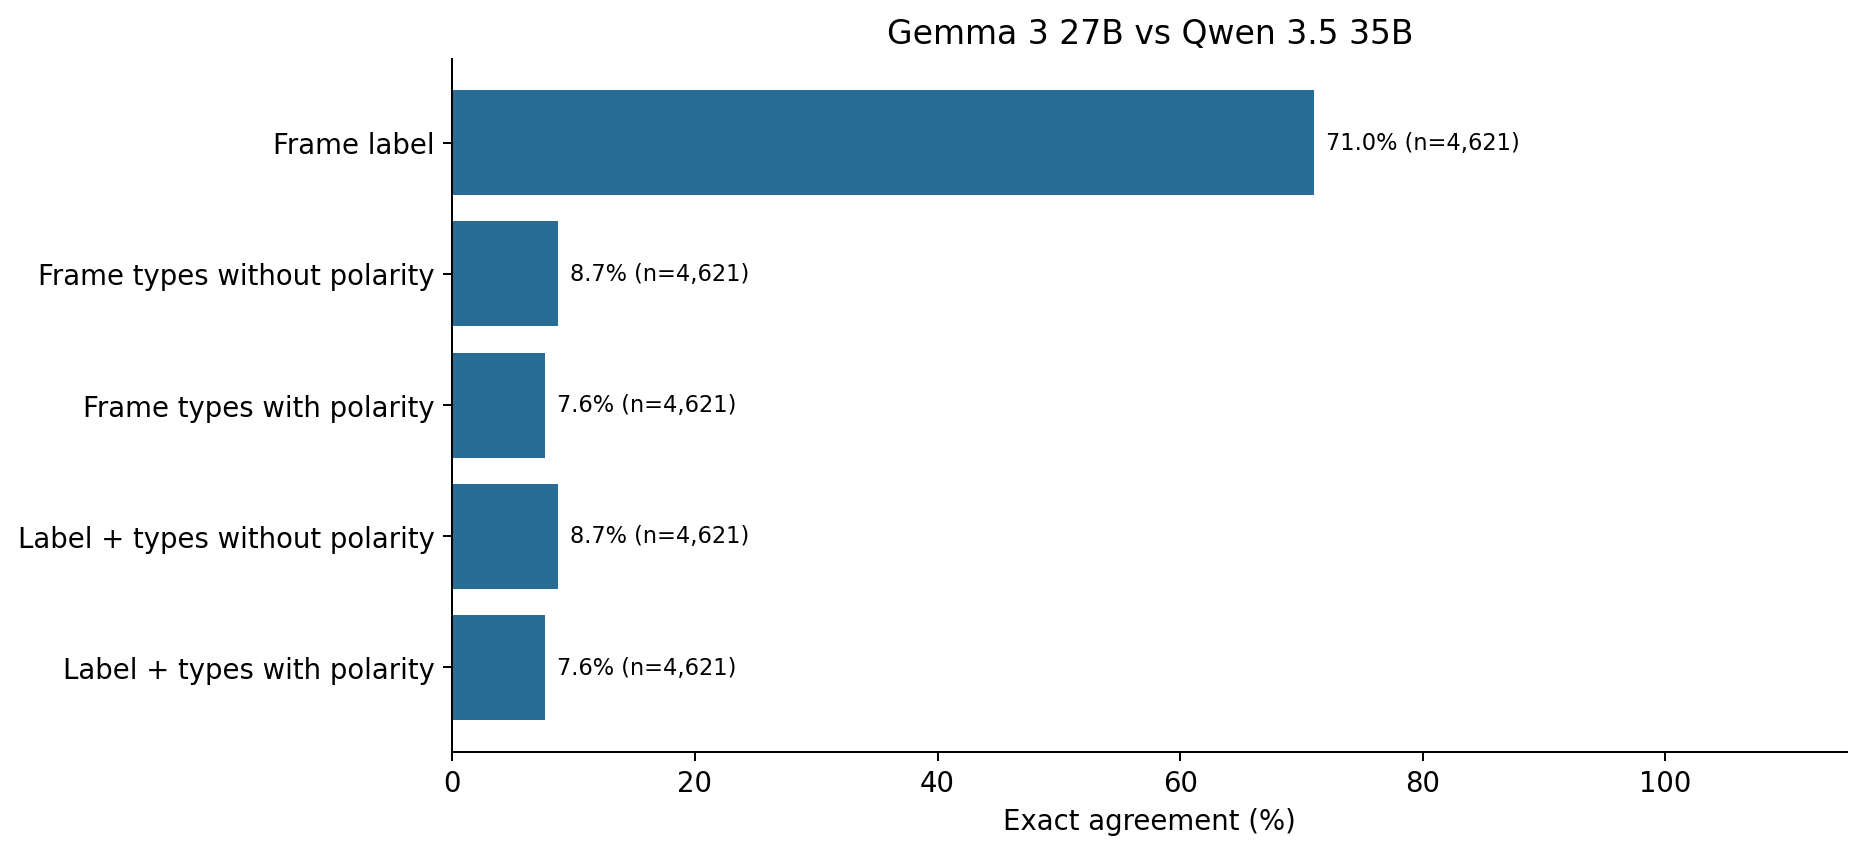

frame_label_confusion.png


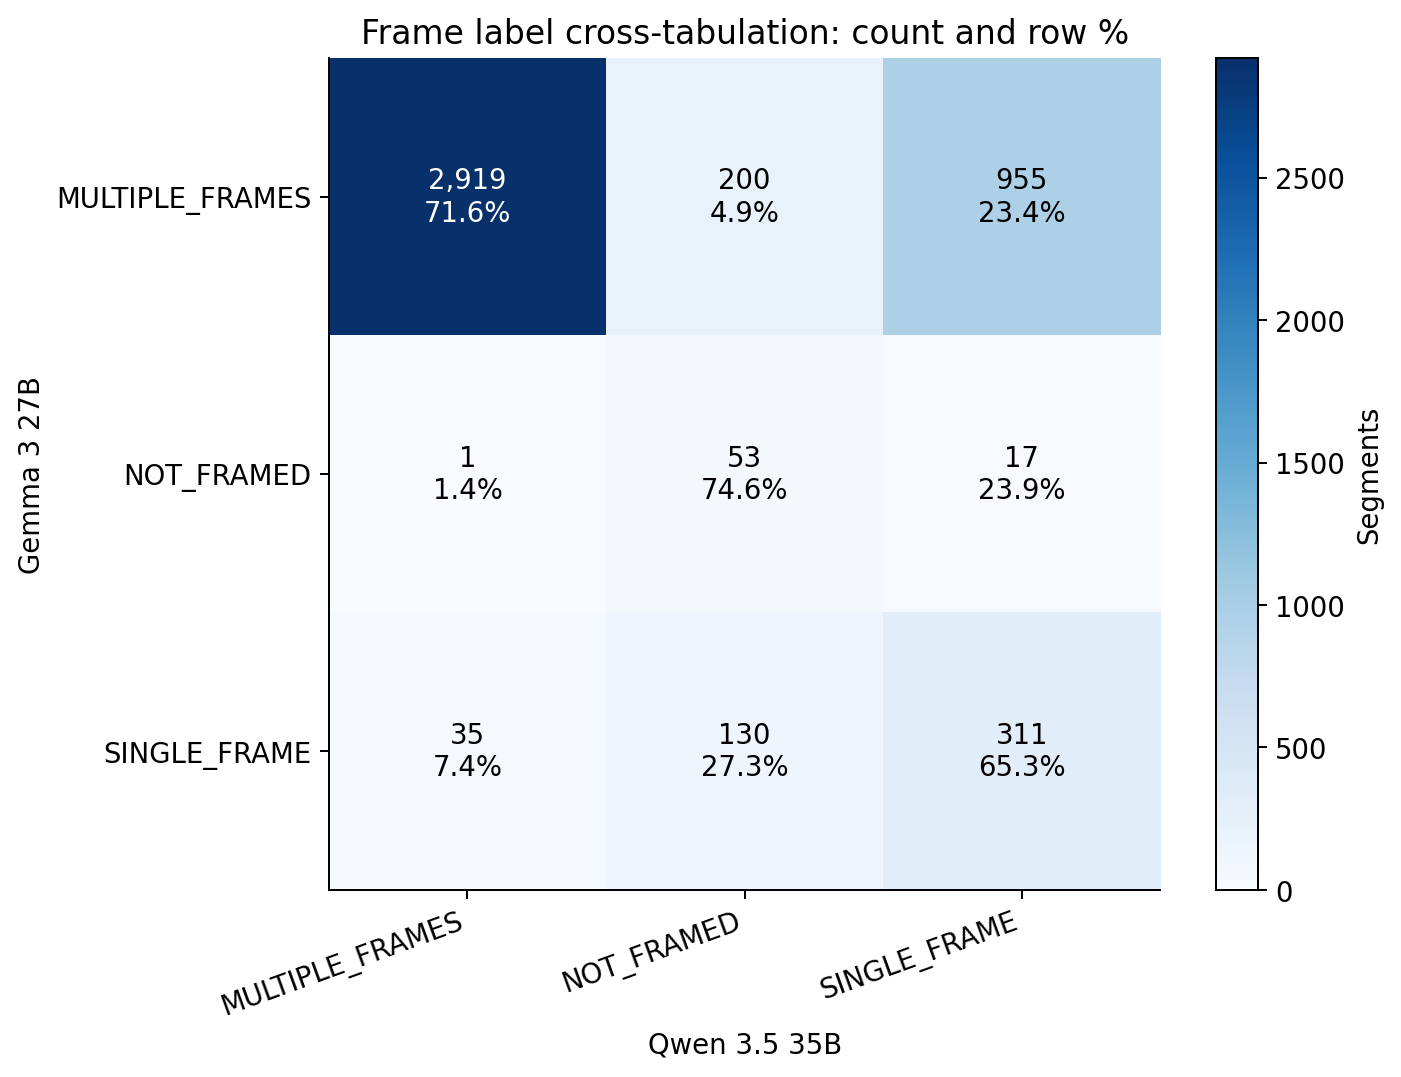

frame_label_distribution.png


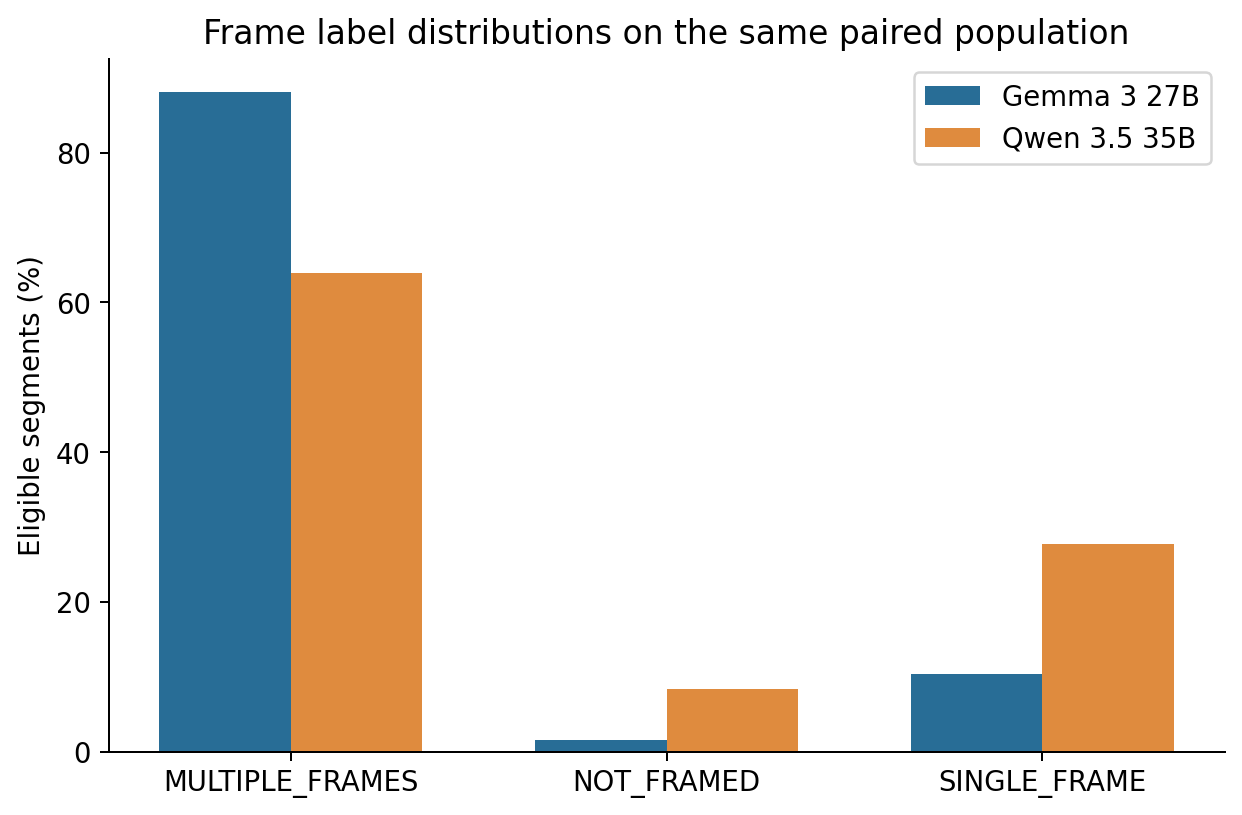

frame_prevalence_without_polarity.png


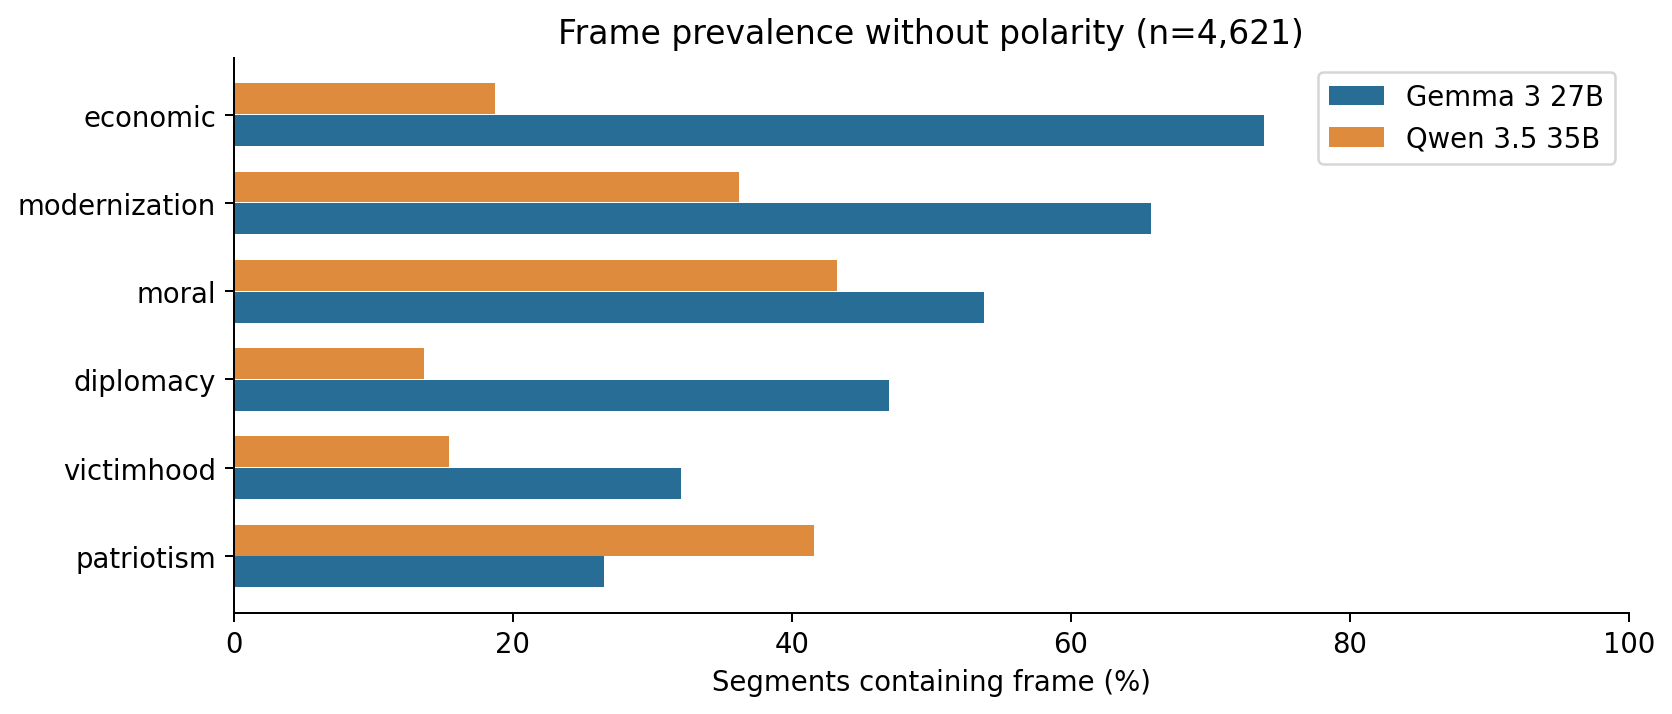

frame_prevalence_with_polarity.png


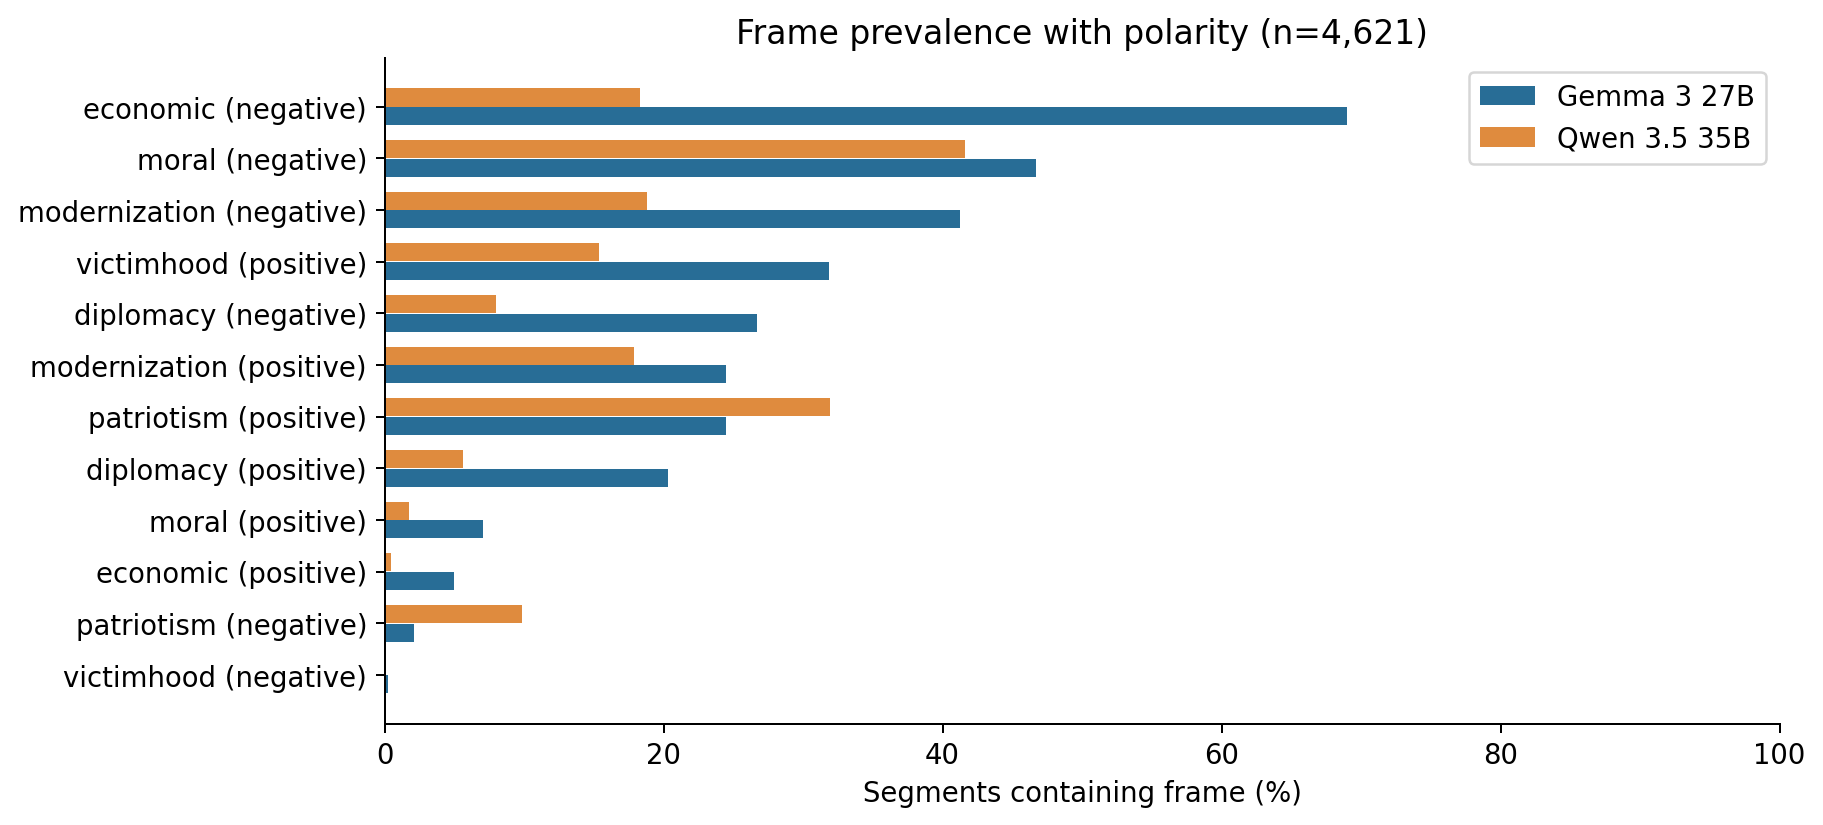

In [30]:
if MAKE_PLOTS:
    charts(summary, confusion, frame_stats, distribution, out, names)
    from PIL import Image
    for filename in [
        'agreement.png', 'frame_label_confusion.png', 'frame_label_distribution.png',
        'frame_prevalence_without_polarity.png', 'frame_prevalence_with_polarity.png'
    ]:
        path = out / filename
        if filename.startswith('frame_prevalence') and frame_stats.empty:
            continue
        if path.exists():
            print(filename)
            with Image.open(path) as image:
                display(image.copy())
else:
    print('Plot generation disabled in settings.')

## 11. Suggested reading order

1. `coverage.json`, `quality_issues.csv`, `unmatched_segments.csv`: verify alignment, exclusions, warnings and coverage.
2. `report.txt`, `agreement_summary.csv`, `agreement.png`: overall exact agreement and denominators.
3. `frame_label_confusion_counts.csv`, `frame_label_confusion_row_percent.csv`, `frame_label_distribution.csv` and their plots: where label differences occur and whether one model predicts more frames.
4. `overlap_summary.csv`: partial overlap and conditional polarity agreement.
5. `per_frame_statistics.csv` and prevalence plots: individual types, shared absence versus positive agreement, and polarity.
6. `agreement_by_group.csv`: differences across topics, gender and decades; check group size.
7. `disagreements_frame_label.csv`, `disagreements_frame_types_without_polarity.csv`, `disagreements_polarity_only.csv`, then signed/joint disagreement files: inspect text, predictions, evidence and explanations. Files overlap; do not add their row counts. `disagreements_any.csv` is their deduplicated union for the first three comparisons.
8. `segment_comparisons.csv`: complete paired audit table, including agreement indicators and eligibility flags.

CSV files use UTF-8 with a BOM for Chinese text in Excel. Files with the same names are overwritten; use a fresh output directory when changing options.


In [32]:
print(f'Results saved to: {out.resolve()}')
display(pd.DataFrame([
    {'file': p.name, 'size_kb': round(p.stat().st_size / 1024, 1)}
    for p in sorted(out.iterdir()) if p.is_file()
]))

Results saved to: /Users/carmand/Desktop/framing/output_updated


,file,size_kb
0,agreement.png,80.4
1,agreement_by_group.csv,7.6
2,agreement_summary.csv,0.5
3,coverage.json,1.0
4,disagreements_any.csv,47546.7
5,disagreements_frame_label.csv,10533.6
6,disagreements_frame_types_with_polarity.csv,47546.7
7,disagreements_frame_types_without_polarity.csv,47002.6
8,disagreements_label_and_types_with_polarity.csv,47546.7
9,disagreements_label_and_types_without_polarity...,47002.6
